In [1]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

## Part a)

beta_0 = vec(2, ..., 1) <br>
beta_1 = 2 * mat_jednostkowa <br>
beta_2 = 0.3 * mat_jednostkowa

In [2]:
rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

## Part b)

In [3]:
r = np.corrcoef(x1, x2)[0, 1]
print("Correlation between x1 and x2:", r)

Correlation between x1 and x2: 0.772324497691354


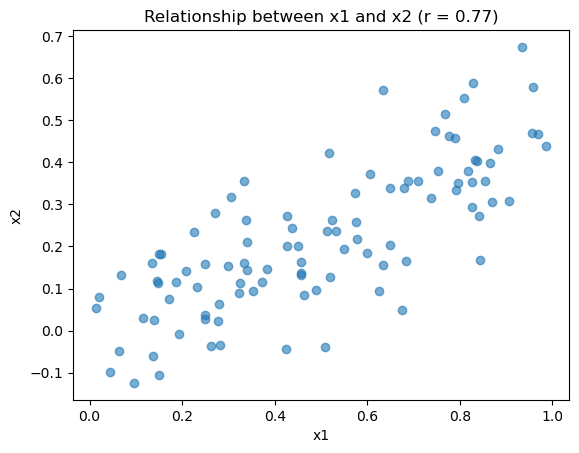

In [4]:
plt.scatter(x1, x2, alpha=0.6)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"Relationship between x1 and x2 (r = {r:.2f})")
plt.show()

## Part c)

Pierwsze dwie wartości są jeszce nie dalekie ale trzecia już odstaje<br>
B_1 = 0 można odrzucić bo p < 0.005 <br>
B_2 = 0 nie można można odrzucić

In [5]:
X = np.column_stack((x1, x2))
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     19.89
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           5.76e-08
Time:                        02:35:13   Log-Likelihood:                -130.62
No. Observations:                 100   AIC:                             267.2
Df Residuals:                      97   BIC:                             275.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9579      0.190     10.319      0.0

## Part d)

Dużo lepiej dopasowane

B_1 = 0 można bo p < 0.005 <br>

In [6]:
X = sm.add_constant(x1)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     38.39
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           1.37e-08
Time:                        02:35:13   Log-Likelihood:                -131.28
No. Observations:                 100   AIC:                             266.6
Df Residuals:                      98   BIC:                             271.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9371      0.189     10.242      0.0

## Part e)

Dalekie wartości od prawdy <br>
B_2 = 0 można odrzucić bo p < 0.005 <br>

In [7]:
X = sm.add_constant(x2)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     27.99
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           7.43e-07
Time:                        02:35:13   Log-Likelihood:                -135.24
No. Observations:                 100   AIC:                             274.5
Df Residuals:                      98   BIC:                             279.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3239      0.154     15.124      0.0

## Part f)

W częściach (c)-(e) otrzymane wyniki nie są sprzeczne. 

Wyniki pokazują różne perspektywy tego samego problemu:

(c) Model z obiema zmiennymi (x1 i x2) pokazuje silny wpływ x1, podczas gdy x2 jest nieistotne statystycznie. Jest to spowodowane współliniowością między zmiennymi.

(d) Model tylko z x1 daje dobre dopasowanie i potwierdza istotność tej zmiennej, co jest zgodne z modelem (c).

(e) Model tylko z x2 również pokazuje istotność tej zmiennej, ale gorsze dopasowanie niż model z x1. Jest to logiczne, ponieważ x2 jest częściowo zależne od x1 i zawiera dodatkowy szum.

Te wyniki wspólnie wskazują, że x1 jest głównym predyktorem, a x2 ma mniejsze znaczenie ze względu na współliniowość zmiennych.

## Part g)

Dodanie nowej obserwacji (x1=0.1, x2=0.8, y=6) znacząco wpływa na wyniki modeli. W każdym przypadku punkt ten jest odstający (outlier), ponieważ jego wartość y jest nietypowo wysoka względem pozostałych danych. Jest to także punkt o dużej dźwigni (high-leverage), szczególnie w modelach, gdzie x1 lub x2 są bliskie wartościom skrajnym w zbiorze. W modelu wielowymiarowym (x1, x2) wpływ tej obserwacji jest nieco mniejszy, ale nadal istotny. W modelach jednowymiarowych (tylko x1 lub tylko x2) punkt ten może silnie zaburzać estymację parametrów, ponieważ leży daleko od większości danych zarówno pod względem zmiennej objaśniającej, jak i wartości y.

In [8]:
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]])

In [9]:
X = np.column_stack((x1, x2))
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.277
Method:                 Least Squares   F-statistic:                     20.17
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           4.60e-08
Time:                        02:35:13   Log-Likelihood:                -135.30
No. Observations:                 101   AIC:                             276.6
Df Residuals:                      98   BIC:                             284.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0618      0.192     10.720      0.0

In [10]:
X = sm.add_constant(x1)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     27.42
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           9.23e-07
Time:                        02:35:13   Log-Likelihood:                -140.37
No. Observations:                 101   AIC:                             284.7
Df Residuals:                      99   BIC:                             290.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0739      0.201     10.310      0.0

In [11]:
X = sm.add_constant(x2)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     36.10
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           3.13e-08
Time:                        02:35:13   Log-Likelihood:                -137.01
No. Observations:                 101   AIC:                             278.0
Df Residuals:                      99   BIC:                             283.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2840      0.151     15.088      0.0